Loading CSV: cookie_cats.csv
Dataset shape: (90189, 5)
Target column selected: retention_7
Dropping 'userid' column
Applied log1p to 'sum_gamerounds'
One-hot encoded 'version' column
Final feature shape: (90189, 4)
Target classes: [0 1]
Class distribution: {0: 73408, 1: 16781}
Features: (90189, 4), Target: (90189,)
Unique classes: [0 1]


/tmp/ipython-input-2440055452.py:463: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y = processed_target.astype(int).ravel()
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/100
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8498 - loss: 0.5235 - val_accuracy: 0.8727 - val_loss: 0.3199
Epoch 2/100
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8659 - loss: 0.3290 - val_accuracy: 0.8695 - val_loss: 0.3138
Epoch 3/100
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8658 - loss: 0.3299 - val_accuracy: 0.8712 - val_loss: 0.3123
Epoch 4/100
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8697 - loss: 0.3214 - val_accuracy: 0.8704 - val_loss: 0.3140
Epoch 5/100
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8682 - loss: 0.3191 - val_accuracy: 0.8677 - val_loss: 0.3198
Epoch 6/100
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8676 - loss: 0.3201 - val_accuracy: 0.8727 - val_loss: 0.3139
Epoch 7/100
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8695 - loss: 0.3198 - val_accuracy: 0.8736 - val_loss: 0.3097
Epoch 8/100
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8712 - loss

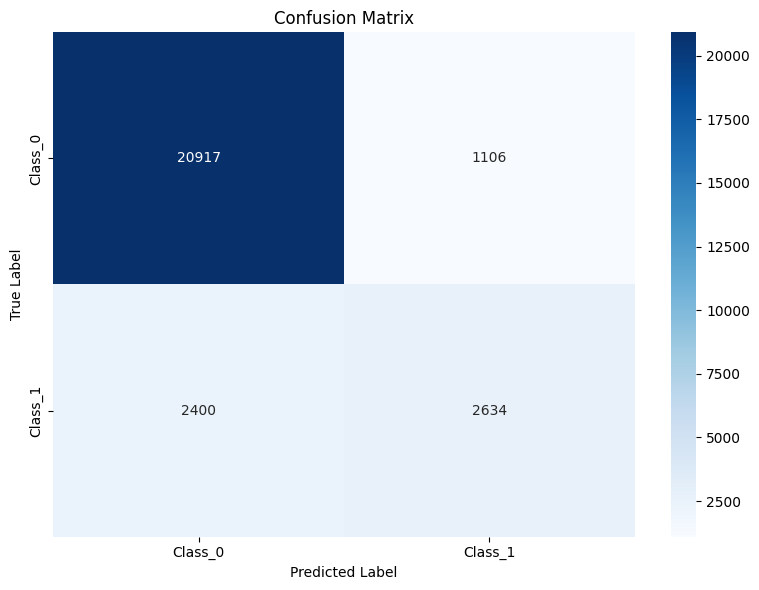


3. Class Distribution:
Class 0: 22023 samples (81.4%)
Class 1: 5034 samples (18.6%)

5. Data Leakage Check:
Baseline calculation failed: invalid index to scalar variable.


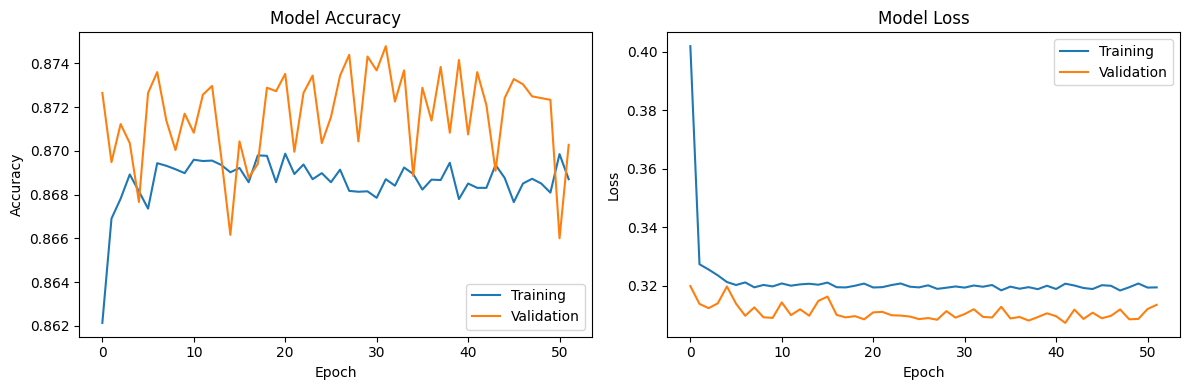

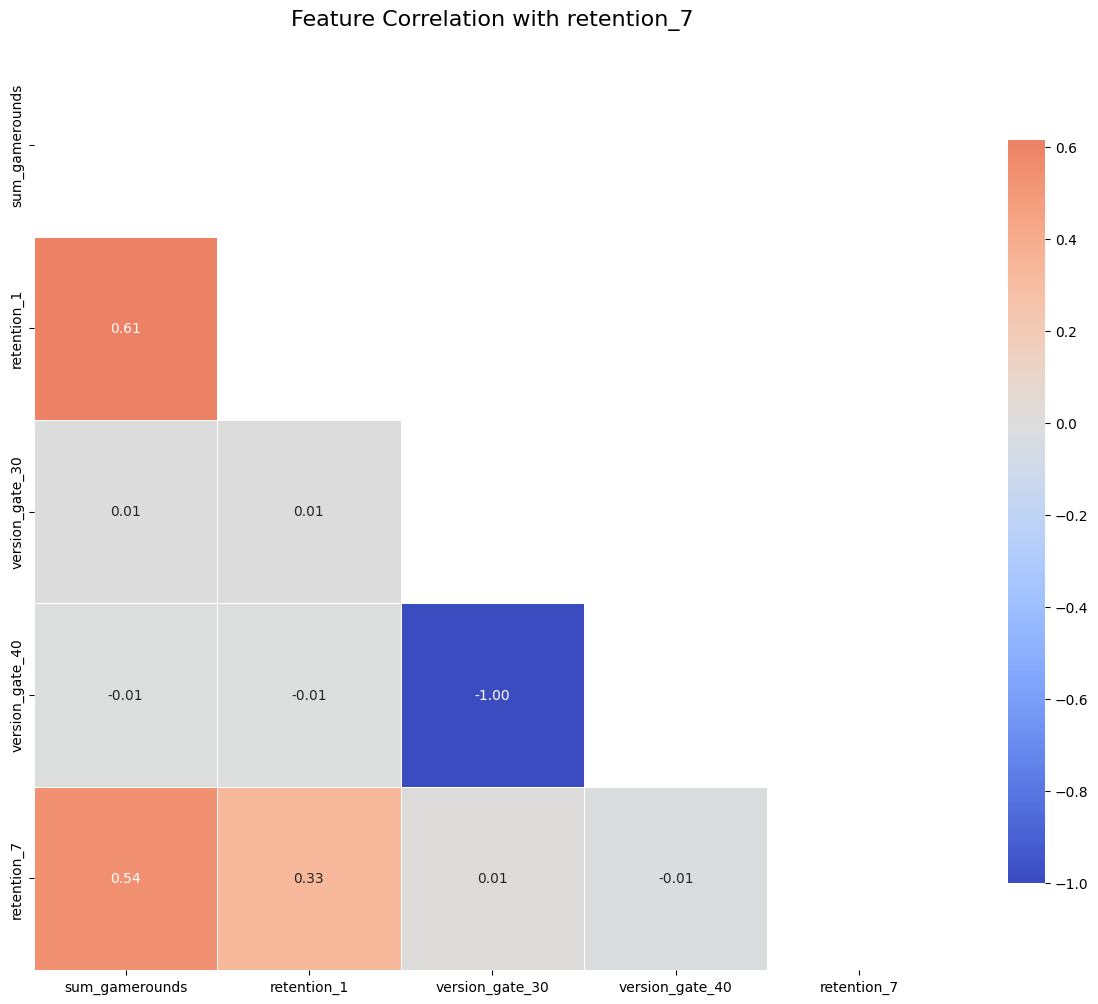


FINAL TEST ACCURACY: 0.8704

MODEL SUMMARY:
  Target: retention_7
  Features: 4
  Classes: 2


In [12]:
import os
import numpy as np
import pandas as pd
import random
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, InputLayer
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import scipy.stats as stats


class DataProcessor:
    """Simplified data processor for machine learning pipelines."""

    def __init__(self, config):
        self.config = config
        self.random_state = random.randint(1, 100)
        pd.set_option('display.max_columns', None)

    def load_dataset(self, path):
        """Load dataset from file path or directory."""
        if path.endswith(".csv") and os.path.isfile(path):
            print(f"Loading CSV: {path}")
            return pd.read_csv(path)

        if os.path.isdir(path):
            return self._load_from_directory(path)

        raise FileNotFoundError(f"Invalid path: {path}")

    def _load_from_directory(self, directory):
        """Load CSV file from directory."""
        files = [f for f in os.listdir(directory) if f.endswith(".csv")]
        if not files:
            raise FileNotFoundError(f"No CSV files in: {directory}")

        if len(files) == 1:
            return pd.read_csv(os.path.join(directory, files[0]))

        print("Available CSV files:")
        for i, f in enumerate(files, 1):
            print(f"{i}: {f}")

        choice = input("Enter number or filename: ").strip()

        if choice.isdigit() and 1 <= int(choice) <= len(files):
            return pd.read_csv(os.path.join(directory, files[int(choice) - 1]))
        elif choice in files:
            return pd.read_csv(os.path.join(directory, choice))

        raise ValueError("Invalid selection.")

    def find_target_column(self, df):
        """Identify target column using multiple strategies."""
        target_candidates = [
            # Primary search
            col for col in df.columns
            if self.config['main_column_name'].lower() in col.lower()
        ]

        # Secondary search
        if not target_candidates and self.config.get('secondary_column_key'):
            target_candidates = [
                col for col in df.columns
                if self.config['secondary_column_key'].lower() in col.lower()
            ]

        # Common target names fallback
        if not target_candidates:
            common_targets = ['target', 'label', 'class', 'output', 'result',
                            'category', 'engagement', 'score', 'rating', 'retention']
            target_candidates = [
                col for col in df.columns
                if any(word in col.lower() for word in common_targets)
            ]

        # Last resort strategies
        if not target_candidates:
            numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
            target_candidates = [numeric_cols[-1]] if numeric_cols else [df.columns[-1]]

        target_col = target_candidates[0]
        print(f"Target column selected: {target_col}")
        return target_col

    def prepare_target_variable(self, target_data):
        """Prepare target variable WITHOUT binning - use original classes."""
        # Clean and convert data
        target_clean = self._clean_target_data(target_data)

        # Convert to integer labels for classification
        # This preserves the original distribution without artificial binning
        if target_clean.dtype == 'object' or not pd.api.types.is_numeric_dtype(target_clean):
            # For categorical data, use label encoding
            target_clean = pd.factorize(target_clean)[0]

        # Ensure we have valid integer labels
        target_clean = target_clean.astype(int)

        print(f"Target classes: {np.unique(target_clean)}")
        print(f"Class distribution: {pd.Series(target_clean).value_counts().to_dict()}")

        return target_clean

    def _clean_target_data(self, data):
        """Clean target data by handling booleans, NaNs, and type conversion."""
        data = data.copy()

        # Handle booleans
        if data.dtype == 'bool':
            data = data.astype(int)

        # Convert to numeric and handle infinities
        data = pd.to_numeric(data, errors='coerce')
        data = data.replace([np.inf, -np.inf], np.nan)

        # Fill NaNs
        if data.isna().any():
            fill_value = data.mode()[0] if data.isna().mean() <= 0.1 else data.median()
            data = data.fillna(fill_value)

        if len(data) == 0:
            raise ValueError("No valid data points after cleaning")

        return data

    def preprocess_features(self, features):
        """Preprocess feature data with common transformations."""
        df = features.copy()

        # Remove identifier columns
        df = self._remove_identifiers(df)

        # Apply common transformations
        df = self._apply_feature_transformations(df)

        # Filter and convert data
        df = self._filter_and_convert_features(df)

        # Handle missing values
        df = self._handle_missing_values(df)

        print(f"Final feature shape: {df.shape}")
        return df.astype(np.float32)

    def _remove_identifiers(self, df):
        """Remove identifier columns like userid."""
        if 'userid' in df.columns:
            print("Dropping 'userid' column")
            return df.drop(columns=['userid'])
        return df

    def _apply_feature_transformations(self, df):
        """Apply common feature transformations."""
        # Log transform skewed features
        if 'sum_gamerounds' in df.columns:
            try:
                df['sum_gamerounds'] = np.log1p(
                    pd.to_numeric(df['sum_gamerounds'], errors='coerce').fillna(0)
                )
                print("Applied log1p to 'sum_gamerounds'")
            except Exception as e:
                print(f"Log transform failed: {e}")

        # One-hot encode categorical features
        if 'version' in df.columns:
            try:
                dummies = pd.get_dummies(df['version'], prefix='version')
                df = pd.concat([df.drop(columns=['version']), dummies], axis=1)
                print("One-hot encoded 'version' column")
            except Exception as e:
                print(f"One-hot encoding failed: {e}")

        return df

    def _filter_and_convert_features(self, df):
        """Filter features and convert to numeric."""
        # Filter by unique values
        df = df.loc[:, df.nunique() <= self.config['max_unique_features']]

        # Convert booleans to integers
        bool_cols = df.select_dtypes(include=['bool']).columns
        df[bool_cols] = df[bool_cols].astype(int)

        # Convert all to numeric
        for col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        return df

    def _handle_missing_values(self, df):
        """Handle missing values in features."""
        for col in df.columns:
            if df[col].isna().any():
                nan_ratio = df[col].isna().mean()

                if nan_ratio > 0.5:
                    print(f"Dropping column {col} ({nan_ratio:.1%} NaN)")
                    df = df.drop(columns=[col])
                else:
                    fill_value = df[col].median() if pd.api.types.is_numeric_dtype(df[col]) else df[col].mode()[0]
                    df[col] = df[col].fillna(fill_value)

        return df

    def select_features(self, features, target, n_features):
        """Select top features using Random Forest importance."""
        if features.shape[1] <= n_features:
            return features.values.astype(np.float32), np.arange(features.shape[1])

        rf = RandomForestClassifier(n_estimators=100, random_state=self.random_state)
        X = features.values.astype(np.float32)
        y = target.astype(int).ravel()

        rf.fit(X, y)
        top_indices = np.argsort(rf.feature_importances_)[-n_features:]

        return X[:, top_indices], top_indices


class ModelBuilder:
    """Simplified model building and training."""

    @staticmethod
    def build_model(input_dim, output_dim):
        """Build neural network model."""
        model = Sequential([
            InputLayer(input_shape=(input_dim,)),
            Dense(64, activation='relu', kernel_regularizer='l2'),
            Dropout(0.3),
            Dense(32, activation='relu', kernel_regularizer='l2'),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dropout(0.1),
            Dense(output_dim, activation='softmax')
        ])

        model.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])
        return model

    @staticmethod
    def train_model(model, X_train, y_train):
        """Train model with early stopping."""
        early_stopping = EarlyStopping(
            monitor='val_loss', patience=10, restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            epochs=100, batch_size=32,
            validation_split=0.2,
            callbacks=[early_stopping],
            shuffle=True,
            verbose=1
        )
        return history


class ResultValidator:
    """Validate and visualize model results."""

    @staticmethod
    def validate_results(model, X_test, y_test, y_pred, target_names=None):
        """Comprehensive model validation."""
        y_test_labels = np.argmax(y_test, axis=1)
        y_pred_labels = np.argmax(y_pred, axis=1)

        actual_classes = np.unique(y_test_labels)
        n_classes = len(actual_classes)

        # Calculate accuracy
        accuracy = accuracy_score(y_test_labels, y_pred_labels)
        print(f"1. Overall Accuracy: {accuracy:.4f}")

        # Classification report
        ResultValidator._print_classification_report(y_test_labels, y_pred_labels,
                                                   actual_classes, target_names, n_classes)

        # Confusion matrix
        ResultValidator._plot_confusion_matrix(y_test_labels, y_pred_labels,
                                            actual_classes, target_names)

        # Additional analyses
        ResultValidator._analyze_class_distribution(y_test_labels)
        ResultValidator._cross_validation_analysis(X_test, y_test_labels)
        ResultValidator._check_data_leakage(X_test, y_test_labels)
        ResultValidator._compare_with_baseline(y_test_labels, accuracy)

        return accuracy

    @staticmethod
    def _print_classification_report(y_true, y_pred, classes, target_names, n_classes):
        """Print classification report."""
        if target_names is None or len(target_names) != n_classes:
            target_names = [f'Class_{i}' for i in classes]

        print("\n2. Classification Report:")
        print(classification_report(y_true, y_pred,
                                  target_names=target_names, labels=classes))

    @staticmethod
    def _plot_confusion_matrix(y_true, y_pred, classes, target_names):
        """Plot confusion matrix."""
        try:
            plt.figure(figsize=(8, 6))
            cm = confusion_matrix(y_true, y_pred, labels=classes)

            if target_names is None or len(target_names) != len(classes):
                target_names = [f'Class_{i}' for i in classes]

            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                       xticklabels=target_names, yticklabels=target_names)
            plt.title('Confusion Matrix')
            plt.ylabel('True Label')
            plt.xlabel('Predicted Label')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Confusion matrix failed: {e}")

    @staticmethod
    def _analyze_class_distribution(y_true):
        """Analyze class distribution."""
        print("\n3. Class Distribution:")
        unique, counts = np.unique(y_true, return_counts=True)
        for cls, count in zip(unique, counts):
            percentage = (count / len(y_true)) * 100
            print(f"Class {cls}: {count} samples ({percentage:.1f}%)")

    @staticmethod
    def _cross_validation_analysis(X, y):
        """Perform cross-validation analysis."""
        if len(X) < 10000:
            print("\n4. Cross-Validation Results:")
            try:
                rf = RandomForestClassifier(n_estimators=50, random_state=42)
                cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
                print(f"CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
            except Exception as e:
                print(f"Cross-validation failed: {e}")

    @staticmethod
    def _check_data_leakage(X, y):
        """Check for potential data leakage."""
        print("\n5. Data Leakage Check:")
        max_corr = 0
        for i in range(X.shape[1]):
            try:
                corr = abs(np.corrcoef(X[:, i], y)[0, 1])
                max_corr = max(max_corr, corr)
            except:
                pass

        if max_corr > 0.95:
            print("WARNING: High feature correlation detected - possible data leakage!")

    @staticmethod
    def _compare_with_baseline(y_true, model_accuracy):
        """Compare model with baseline performance."""
        try:
            majority_class = stats.mode(y_true)[0][0]
            baseline_accuracy = np.mean(y_true == majority_class)
            improvement = model_accuracy - baseline_accuracy

            print(f"\n6. Baseline (Majority Class): {baseline_accuracy:.4f}")
            print(f"Model improvement: {improvement:.4f}")
        except Exception as e:
            print(f"Baseline calculation failed: {e}")


def plot_training_history(history):
    """Plot training history."""
    try:
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(history.history.get('accuracy', []), label='Training')
        plt.plot(history.history.get('val_accuracy', []), label='Validation')
        plt.title('Model Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(history.history.get('loss', []), label='Training')
        plt.plot(history.history.get('val_loss', []), label='Validation')
        plt.title('Model Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not plot training history: {e}")


def plot_correlation_heatmap(data, title="Correlation Matrix"):
    """Plot correlation heatmap."""
    try:
        numeric_data = data.select_dtypes(include=[np.number])
        if numeric_data.empty:
            print("No numeric columns for correlation heatmap")
            return

        corr_matrix = numeric_data.corr()
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

        plt.figure(figsize=(12, 10))
        sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
                   center=0, square=True, linewidths=0.5, cbar_kws={"shrink": .8})
        plt.title(title, fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Correlation heatmap failed: {e}")


def main():
    config = {
        'feature_selection_amount': 12,
        'main_column_name': 'retention_7',
        'secondary_column_key': None,
        'max_unique_features': 10000000,
        'plot_correlation': True,
    }

    processor = DataProcessor(config)
    model_builder = ModelBuilder()
    validator = ResultValidator()

    try:
        # Load and prepare data
        data = processor.load_dataset(path="cookie_cats.csv")
        print(f"Dataset shape: {data.shape}")

        # Convert boolean columns
        bool_cols = data.select_dtypes(include=['bool']).columns
        data[bool_cols] = data[bool_cols].astype(int)

        # Find target and features
        target_column = processor.find_target_column(data)
        target_data = data[target_column]
        feature_data = data.drop(columns=[target_column])

        # Preprocess
        processed_features = processor.preprocess_features(feature_data)

        # Prepare target WITHOUT binning - use original classes
        processed_target = processor.prepare_target_variable(target_data)

        # Prepare arrays
        X = processed_features.values.astype(np.float32)
        y = processed_target.astype(int).ravel()

        print(f"Features: {X.shape}, Target: {y.shape}")
        print(f"Unique classes: {np.unique(y)}")

        # Normalize and select features
        scaler = StandardScaler()
        X_normalized = scaler.fit_transform(X)

        n_features = min(config['feature_selection_amount'], X_normalized.shape[1])
        X_selected, _ = processor.select_features(
            pd.DataFrame(X_normalized), y, n_features
        )

        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X_selected, y, test_size=0.3, random_state=processor.random_state, stratify=y
        )

        # Prepare categorical targets
        num_classes = len(np.unique(y))
        y_train_cat = to_categorical(y_train, num_classes=num_classes)
        y_test_cat = to_categorical(y_test, num_classes=num_classes)

        # Build and train model
        model = model_builder.build_model(X_train.shape[1], num_classes)
        history = model_builder.train_model(model, X_train, y_train_cat)

        # Evaluate
        y_pred = model.predict(X_test)
        accuracy = validator.validate_results(model, X_test, y_test_cat, y_pred)

        # Visualizations
        plot_training_history(history)

        if config.get('plot_correlation', True):
            combined_data = pd.concat([processed_features, processed_target], axis=1)
            plot_correlation_heatmap(combined_data, f"Feature Correlation with {target_column}")

        # Final summary
        print(f"\nFINAL TEST ACCURACY: {accuracy:.4f}")
        if accuracy > 0.95:
            print("WARNING: Very high accuracy - check for data leakage")

        print(f"\nMODEL SUMMARY:")
        print(f"  Target: {target_column}")
        print(f"  Features: {X_selected.shape[1]}")
        print(f"  Classes: {num_classes}")

    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()


if __name__ == "__main__":
    main()